In [43]:
!unzip -o /content/csv_for_run.zip -d /content/csv_for_run


Archive:  /content/csv_for_run.zip
  inflating: /content/csv_for_run/csv_for_run/50_users_tracks_top15_enriched_.csv  
  inflating: /content/csv_for_run/csv_for_run/generated_profiles_deepseek.csv  
  inflating: /content/csv_for_run/csv_for_run/generated_profiles_gemini.csv  
  inflating: /content/csv_for_run/csv_for_run/generated_profiles_llama.csv  
  inflating: /content/csv_for_run/csv_for_run/test_candidates_with_gemini_llama_deepseek_profile_ids.csv  
  inflating: /content/csv_for_run/csv_for_run/test_pool_500_set.csv  
  inflating: /content/csv_for_run/csv_for_run/train_pool_1000_set.csv  
  inflating: /content/csv_for_run/csv_for_run/train_triplets_with_gemini_llama_deepseek_profile_ids.csv  


In [44]:
# =========================
# Bi-Encoder Training + Evaluation (Gemini + LLaMA + DeepSeek)
# =========================

!pip -q install sentence-transformers tqdm

import os, random
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm

from torch.utils.data import DataLoader
from sentence_transformers import SentenceTransformer, InputExample
from sentence_transformers import losses

# -------------------------
# PATHS
# -------------------------
TRAIN_CSV = "/content/csv_for_run/csv_for_run/train_triplets_with_gemini_llama_deepseek_profile_ids.csv"
TEST_CSV  = "/content/csv_for_run/csv_for_run/test_candidates_with_gemini_llama_deepseek_profile_ids.csv"

PROFILES_GEMINI   = "/content/csv_for_run/csv_for_run/generated_profiles_gemini.csv"
PROFILES_LLAMA    = "/content/csv_for_run/csv_for_run/generated_profiles_llama.csv"
PROFILES_DEEPSEEK = "/content/csv_for_run/csv_for_run/generated_profiles_deepseek.csv"

POS_META   = "/content/csv_for_run/csv_for_run/50_users_tracks_top15_enriched_.csv"
TRAIN_POOL = "/content/csv_for_run/csv_for_run/train_pool_1000_set.csv"
TEST_POOL  = "/content/csv_for_run/csv_for_run/test_pool_500_set.csv"

# -------------------------
# SETTINGS
# -------------------------
BASE_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
BATCH_SIZE = 10
EPOCHS = 1
MAX_LEN = 512
LR = 2e-5

SEEDS = [42]
TOPK = 10


In [45]:
# -------------------------
# Helpers
# -------------------------
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def track_key(artist, title):
    a = "" if pd.isna(artist) else str(artist).strip()
    t = "" if pd.isna(title) else str(title).strip()
    return f"{a}|||{t}"

def safe_str(x):
    return "" if pd.isna(x) else str(x).strip()

def build_track_text(row, artist_col="artist_name", title_col="track_name"):
    title = safe_str(row.get(title_col, ""))
    artist = safe_str(row.get(artist_col, ""))

    year = safe_str(row.get("release_year", ""))
    country = safe_str(row.get("origin_country", ""))
    main_genre = safe_str(row.get("main_genre", ""))
    secondary = safe_str(row.get("secondary_genres", ""))

    parts = []
    if title:  parts.append(f"Title: {title}")
    if artist: parts.append(f"Artist: {artist}")
    if year:   parts.append(f"Year: {year}")
    if country:parts.append(f"Country: {country}")
    if main_genre: parts.append(f"Main genre: {main_genre}")
    if secondary:  parts.append(f"Secondary genres: {secondary}")

    return " | ".join(parts)

def recall_at_k(sorted_labels, k=10):
    return 1.0 if sum(sorted_labels[:k]) > 0 else 0.0

def ndcg_at_k(sorted_labels, k=10):
    rel = np.array(sorted_labels[:k], dtype=float)
    if rel.sum() == 0:
        return 0.0
    gains = rel / np.log2(np.arange(2, k + 2))
    dcg = gains.sum()
    ideal_rel = np.sort(rel)[::-1]
    ideal_gains = ideal_rel / np.log2(np.arange(2, k + 2))
    idcg = ideal_gains.sum()
    return float(dcg / idcg) if idcg > 0 else 0.0


In [46]:

# -------------------------
# Load data
# -------------------------
train = pd.read_csv(TRAIN_CSV, encoding="utf-8-sig")
test  = pd.read_csv(TEST_CSV,  encoding="utf-8-sig")

gem = pd.read_csv(PROFILES_GEMINI,   encoding="utf-8-sig")
lla = pd.read_csv(PROFILES_LLAMA,    encoding="utf-8-sig")
dsk = pd.read_csv(PROFILES_DEEPSEEK, encoding="utf-8-sig")

pos_meta   = pd.read_csv(POS_META,   encoding="utf-8-sig")
train_pool = pd.read_csv(TRAIN_POOL, encoding="utf-8-sig")
test_pool  = pd.read_csv(TEST_POOL,  encoding="utf-8-sig")

# -------------------------
# Build profile lookup: profile_id -> profile_text
# -------------------------
def build_profile_lookup(df_profiles: pd.DataFrame):
    for c in ["profile_id", "profile_text"]:
        if c not in df_profiles.columns:
            raise ValueError(f"Profiles missing '{c}'. Found: {df_profiles.columns.tolist()}")
    return dict(zip(df_profiles["profile_id"].astype(str), df_profiles["profile_text"].astype(str)))

profile_text = {}
profile_text.update(build_profile_lookup(gem))
profile_text.update(build_profile_lookup(lla))
profile_text.update(build_profile_lookup(dsk))

# -------------------------
# Build track lookup: track_key -> track_text
# -------------------------
def build_track_lookup():
    pieces = []
    for df in [pos_meta, train_pool, test_pool]:
        if "artist_name" not in df.columns or "track_name" not in df.columns:
            raise ValueError(f"Missing artist_name/track_name in metadata. Found: {df.columns.tolist()}")
        tmp = df.copy()
        tmp["__track_key__"] = tmp.apply(lambda r: track_key(r["artist_name"], r["track_name"]), axis=1)
        tmp["__track_text__"] = tmp.apply(lambda r: build_track_text(r, "artist_name", "track_name"), axis=1)
        pieces.append(tmp[["__track_key__", "__track_text__"]])
    all_meta = pd.concat(pieces, ignore_index=True).drop_duplicates("__track_key__")
    return dict(zip(all_meta["__track_key__"], all_meta["__track_text__"]))

track_text = build_track_lookup()

# -------------------------
# Profile id columns in train/test
# -------------------------
PROFILE_COLUMNS = {
    ("gemini",   "rec_optimized"): "profile_id_rec_gemini",
    ("gemini",   "user_facing"):   "profile_id_uf_gemini",
    ("llama",    "rec_optimized"): "profile_id_rec_llama",
    ("llama",    "user_facing"):   "profile_id_uf_llama",
    ("deepseek", "rec_optimized"): "profile_id_rec_deepseek",
    ("deepseek", "user_facing"):   "profile_id_uf_deepseek",
}

for (llm, ptype), col in PROFILE_COLUMNS.items():
    if col not in train.columns or col not in test.columns:
        raise ValueError(f"Missing '{col}' in train/test. Train cols: {train.columns.tolist()}")

In [47]:
# =========================
# Subsample to 20 users
# =========================
N_USERS = 20
SEED_USERS = 42

rng = np.random.RandomState(SEED_USERS)

# pick 20 users from TRAIN
all_users = train["user_id"].dropna().astype(str).unique()
if len(all_users) < N_USERS:
    raise ValueError(f"Only found {len(all_users)} users in train, cannot pick {N_USERS}.")

picked_users = rng.choice(all_users, size=N_USERS, replace=False)
picked_users = set(picked_users)

def filter_users(df, user_col="user_id"):
    return df[df[user_col].astype(str).isin(picked_users)].copy()

# Filter datasets
train = filter_users(train, "user_id")
test  = filter_users(test,  "user_id")

# Filter profiles
gem = filter_users(gem, "user_id")
lla = filter_users(lla, "user_id")
# If you also load deepseek profiles:
# dee = filter_users(dee, "user_id")

# Filter positives metadata
pos_meta = filter_users(pos_meta, "user_id")

# train_pool = train_pool
# test_pool  = test_pool

print("Using users:", len(picked_users))
print("Train rows:", len(train), "| Test rows:", len(test))
print("Gem profiles:", len(gem), "| LLaMA profiles:", len(lla))
print("Pos meta rows:", len(pos_meta))
print("Train pool rows:", len(train_pool), "| Test pool rows:", len(test_pool))


Using users: 20
Train rows: 24000 | Test rows: 8800
Gem profiles: 160 | LLaMA profiles: 160
Pos meta rows: 1200
Train pool rows: 1000 | Test pool rows: 500


In [48]:
# -------------------------
# Build training triplets
# -------------------------
def build_triplet_examples(llm: str, profile_type: str):
    pid_col = PROFILE_COLUMNS[(llm, profile_type)]
    needed = [pid_col, "pos_artist_name", "pos_track_name", "neg_artist_name", "neg_track_name"]
    missing = [c for c in needed if c not in train.columns]
    if missing:
        raise ValueError(f"Train missing {missing}")

    examples, bad = [], 0
    for r in train.itertuples(index=False):
        pid = getattr(r, pid_col)
        if pd.isna(pid):
            bad += 1
            continue

        q = profile_text.get(str(pid), "")
        if not q:
            bad += 1
            continue

        pos_k = track_key(getattr(r, "pos_artist_name"), getattr(r, "pos_track_name"))
        neg_k = track_key(getattr(r, "neg_artist_name"), getattr(r, "neg_track_name"))

        pos_t = track_text.get(pos_k, "")
        neg_t = track_text.get(neg_k, "")
        if not pos_t or not neg_t:
            bad += 1
            continue

        examples.append(InputExample(texts=[q, pos_t, neg_t]))

    print(f"[{llm}/{profile_type}] triplets = {len(examples)} (skipped {bad})")
    return examples

In [49]:
# -------------------------
# Train
# -------------------------
def train_biencoder(llm: str, profile_type: str, seed: int):
    set_seed(seed)

    model = SentenceTransformer(BASE_MODEL_NAME)
    model.max_seq_length = MAX_LEN

    train_examples = build_triplet_examples(llm, profile_type)
    train_loader = DataLoader(train_examples, batch_size=BATCH_SIZE, shuffle=True)

    train_loss = losses.TripletLoss(model=model)

    out_path = os.path.join(OUT_DIR, f"model_{llm}_{profile_type}_seed{seed}")
    model.fit(
        train_objectives=[(train_loader, train_loss)],
        epochs=EPOCHS,
        optimizer_params={"lr": LR},
        show_progress_bar=True,
        output_path=out_path
    )
    return out_path


In [50]:
# -------------------------
# Evaluate
# -------------------------

def evaluate_model(model_path: str, llm: str, profile_type: str, seed: int):
    set_seed(seed)
    model = SentenceTransformer(model_path)
    model.max_seq_length = MAX_LEN

    pid_col = PROFILE_COLUMNS[(llm, profile_type)]
    needed = ["query_key", "user_id", "time_window_days", pid_col, "artist_name", "track_name", "label"]
    missing = [c for c in needed if c not in test.columns]
    if missing:
        raise ValueError(f"Test missing {missing}")

    rows = []
    for qk, g in test.groupby("query_key"):
        pid = g[pid_col].iloc[0]
        if pd.isna(pid):
            continue

        qtext = profile_text.get(str(pid), "")
        if not qtext:
            continue

        cand_keys  = g.apply(lambda r: track_key(r["artist_name"], r["track_name"]), axis=1).tolist()
        cand_texts = [track_text.get(k, "") for k in cand_keys]
        labels     = g["label"].astype(int).tolist()

        keep = [i for i, t in enumerate(cand_texts) if t]
        if len(keep) < 5:
            continue

        cand_texts = [cand_texts[i] for i in keep]
        labels     = [labels[i] for i in keep]

        q_emb = model.encode([qtext], convert_to_tensor=True)
        c_emb = model.encode(cand_texts, convert_to_tensor=True)

        sims = torch.nn.functional.cosine_similarity(q_emb, c_emb)
        order = torch.argsort(sims, descending=True).cpu().numpy().tolist()

        sorted_labels = [labels[i] for i in order]
        r10 = recall_at_k(sorted_labels, TOPK)
        n10 = ndcg_at_k(sorted_labels, TOPK)

        rows.append({
            "seed": seed,
            "llm": llm,
            "profile_type": profile_type,
            "query_key": qk,
            "recall@10": r10,
            "ndcg@10": n10,
        })

    return pd.DataFrame(rows)


In [51]:
# -------------------------
# FAST RUN FOR 1 SEED
# -------------------------
SEEDS = [42]
OUT_DIR = "/content/eval_outputs_seed42/"
os.makedirs(OUT_DIR, exist_ok=True)

all_results = []

for llm in ["gemini", "llama", "deepseek"]:
    for ptype in ["rec_optimized", "user_facing"]:
        for seed in SEEDS:
            print(f"\n=== TRAIN {llm}/{ptype} seed={seed} ===")
            model_path = train_biencoder(llm, ptype, seed)

            print(f"=== EVAL  {llm}/{ptype} seed={seed} ===")
            res = evaluate_model(model_path, llm, ptype, seed)

            out_csv = os.path.join(OUT_DIR, f"results_{llm}_{ptype}_seed{seed}.csv")
            res.to_csv(out_csv, index=False)
            print("Saved per-seed results:", out_csv, "| rows:", len(res))

            all_results.append(res)

all_results = pd.concat(all_results, ignore_index=True)
all_long_path = os.path.join(OUT_DIR, "all_results_long_seed42.csv")
all_results.to_csv(all_long_path, index=False)
print("\nSaved:", all_long_path)

summary = (
    all_results
    .groupby(["llm", "profile_type"])
    .agg(
        recall10_mean=("recall@10", "mean"),
        recall10_std=("recall@10", "std"),
        ndcg10_mean=("ndcg@10", "mean"),
        ndcg10_std=("ndcg@10", "std"),
        n=("recall@10", "count"),
    )
    .reset_index()
)

summary_path = os.path.join(OUT_DIR, "summary_mean_std_seed42.csv")
summary.to_csv(summary_path, index=False)

print("\n=== SUMMARY (seed=42) ===")
print(summary.to_string(index=False))
print("\nSaved summary:", summary_path)



=== TRAIN gemini/rec_optimized seed=42 ===


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[gemini/rec_optimized] triplets = 23140 (skipped 860)


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

...

Step,Training Loss
500,5.042970
1000,4.982371
1500,4.828967
2000,4.489069


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

=== EVAL  deepseek/user_facing seed=42 ===


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Saved per-seed results: /content/eval_outputs_seed42/results_deepseek_user_facing_seed42.csv | rows: 80

Saved: /content/eval_outputs_seed42/all_results_long_seed42.csv

=== SUMMARY (seed=42) ===
     llm  profile_type  recall10_mean  recall10_std  ndcg10_mean  ndcg10_std  n
deepseek rec_optimized         0.0625      0.243589     0.038313    0.169503 80
deepseek   user_facing         0.0750      0.265053     0.027146    0.097486 80
  gemini rec_optimized         0.0500      0.219320     0.033779    0.165273 80
  gemini   user_facing         0.0250      0.157110     0.014137    0.089449 80
   llama rec_optimized         0.1000      0.301893     0.045295    0.152993 80
   llama   user_facing         0.0500      0.219320     0.015772    0.069417 80

Saved summary: /content/eval_outputs_seed42/summary_mean_std_seed42.csv


Explanation about the difference in standard deviation

The standard deviation values differ between the five-seed setting and the single-seed setting because they measure two different sources of variability.

When we report results over five seeds, we first compute the average performance per seed (averaged across all queries), and then compute the standard deviation across the five seed-level means. In this case, the standard deviation reflects variability caused by random initialization and stochastic training effects. Since the model behavior across seeds is relatively consistent, this variability is small, resulting in low standard deviation values.

In contrast, when running only a single seed, the standard deviation (if computed across queries) reflects variability across individual queries within that run. Query-level performance varies substantially — some queries are easy and achieve Recall@10 = 1, while many achieve 0 — which naturally produces a much larger standard deviation. This does not indicate instability in training, but rather the inherent difficulty differences across queries.

Therefore, the smaller standard deviation in the five-seed experiments reflects stability across runs, while the larger standard deviation in the single-seed setting reflects variability across queries.

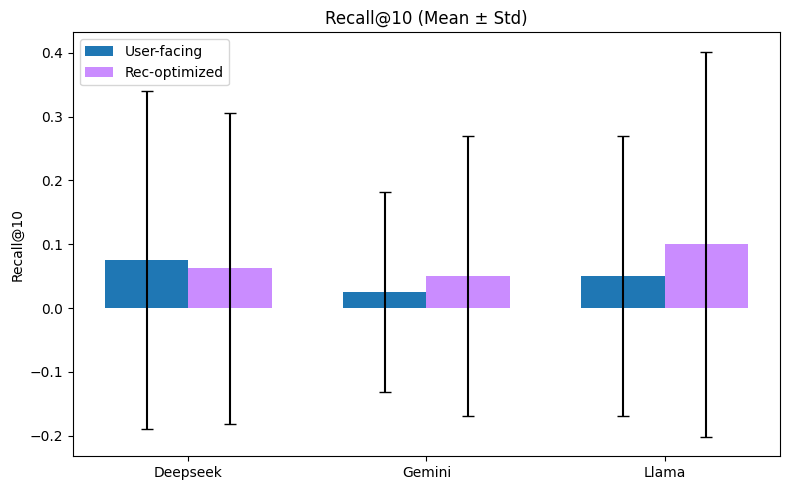

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# PATH
# =========================
CSV_PATH = "/content/eval_outputs_seed42/summary_mean_std_seed42.csv"

# =========================
# LOAD
# =========================
df = pd.read_csv(CSV_PATH)

# Make model names prettier
df["LLM"] = df["llm"].str.capitalize()
df["profile_type"] = df["profile_type"].replace({
    "user_facing": "User-facing",
    "rec_optimized": "Rec-optimized"
})

models = sorted(df["LLM"].astype(str).unique().tolist())

# =========================
# PREP DATA
# =========================
recall_user = []
recall_user_std = []
recall_rec = []
recall_rec_std = []

for m in models:
    user_row = df[(df["LLM"] == m) & (df["profile_type"] == "User-facing")].iloc[0]
    rec_row  = df[(df["LLM"] == m) & (df["profile_type"] == "Rec-optimized")].iloc[0]

    recall_user.append(user_row["recall10_mean"])
    recall_user_std.append(user_row["recall10_std"])

    recall_rec.append(rec_row["recall10_mean"])
    recall_rec_std.append(rec_row["recall10_std"])

# =========================
# PLOT
# =========================
x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, recall_user, width,
        yerr=recall_user_std,
        capsize=4,
        label="User-facing")

plt.bar(x + width/2, recall_rec, width,
        yerr=recall_rec_std,
        capsize=4,
        label="Rec-optimized",
        color="#CA8CFF")

plt.xticks(x, models)
plt.ylabel("Recall@10")
plt.title("Recall@10 (Mean ± Std)")
plt.legend()
plt.tight_layout()

plt.savefig("/content/recall_plot_from_csv.png", dpi=300)
plt.show()


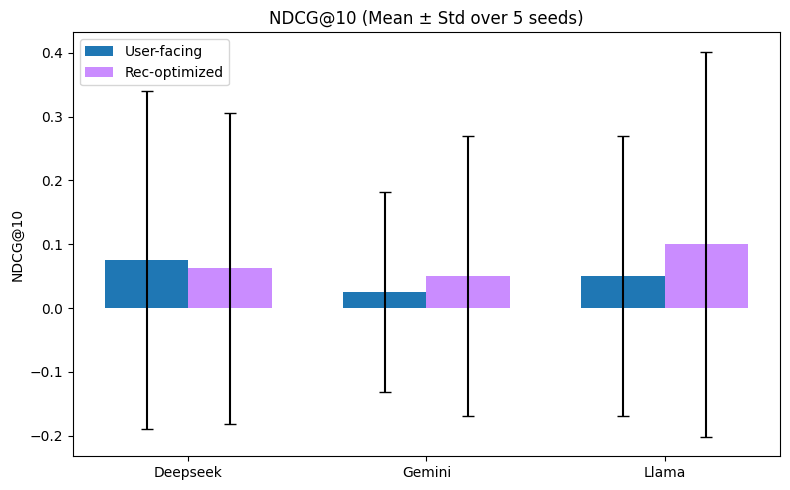

In [53]:
ndcg_user = []
ndcg_user_std = []
ndcg_rec = []
ndcg_rec_std = []

for m in models:
    user_row = df[(df["LLM"] == m) & (df["profile_type"] == "User-facing")].iloc[0]
    rec_row  = df[(df["LLM"] == m) & (df["profile_type"] == "Rec-optimized")].iloc[0]

    ndcg_user.append(user_row["ndcg10_mean"])
    ndcg_user_std.append(user_row["ndcg10_std"])

    ndcg_rec.append(rec_row["ndcg10_mean"])
    ndcg_rec_std.append(rec_row["ndcg10_std"])

# =========================
# PLOT
# =========================
x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, recall_user, width,
        yerr=recall_user_std,
        capsize=4,
        label="User-facing")

plt.bar(x + width/2, recall_rec, width,
        yerr=recall_rec_std,
        capsize=4,
        label="Rec-optimized",
        color="#CA8CFF")

plt.xticks(x, models)
plt.ylabel("NDCG@10")
plt.title("NDCG@10 (Mean ± Std over 5 seeds)")
plt.legend()
plt.tight_layout()

plt.savefig("/content/NDCG10_plot_from_csv.png", dpi=300)
plt.show()



In [54]:

import re
import pandas as pd
from collections import defaultdict

# =========================
# PATHS
# =========================
PROFILES_CSVS = [
    ("/content/csv_for_run/csv_for_run/generated_profiles_gemini.csv", "gemini"),
    ("/content/csv_for_run/csv_for_run/generated_profiles_llama.csv",  "llama"),
    ("/content/csv_for_run/csv_for_run/generated_profiles_deepseek.csv", "deepseek"),
]

EVIDENCE_TOP15 = "/content/csv_for_run/csv_for_run/50_users_tracks_top15_enriched_.csv"

OUT_PER_PROFILE = "/content/biasA_faithfulness_per_profile.csv"
OUT_SUMMARY     = "/content/biasA_faithfulness_summary.csv"

# =========================
# Robust CSV load + helpers
# =========================
def read_csv_robust(path):
    try:
        return pd.read_csv(path, encoding="utf-8-sig")
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding="latin1")

def norm_str(x):
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return ""
    return str(x).strip()

TOKEN_RE = re.compile(r"[a-z0-9]+", re.I)
YEAR_RE  = re.compile(r"\b(19|20)\d{2}\b")

def tokenize(text):
    return set(TOKEN_RE.findall(text.lower()))

def split_multi(x):
    """
    Split genre-like fields that can be:
    - comma separated
    - semicolon separated
    - pipe separated
    """
    s = norm_str(x).lower()
    if not s:
        return []
    s = s.replace("|", ",").replace(";", ",")
    parts = [p.strip() for p in s.split(",")]
    return [p for p in parts if p]


In [55]:
# =========================
# 1) Build evidence sets per (user_id, time_window_days)
# =========================
ev = read_csv_robust(EVIDENCE_TOP15)

# detect likely column names
def pick_col(cols, candidates):
    cols_l = {c.lower(): c for c in cols}
    for cand in candidates:
        if cand in cols_l:
            return cols_l[cand]
    # fallback: contains match
    for c in cols:
        cl = c.lower()
        for cand in candidates:
            if cand in cl:
                return c
    return None

col_user = pick_col(ev.columns, ["user_id", "userid", "user"])
col_tw   = pick_col(ev.columns, ["time_window_days", "timewindow_days", "window_days", "time_window"])
col_artist = pick_col(ev.columns, ["artist_name", "artist"])
col_track  = pick_col(ev.columns, ["track_name", "track", "title"])
col_country = pick_col(ev.columns, ["origin_country", "country", "artist_country"])
col_main_genre = pick_col(ev.columns, ["main_genre", "genre_main", "primary_genre", "genre"])
col_sec_genres = pick_col(ev.columns, ["secondary_genres", "secondary_genre", "genres_secondary", "subgenres"])
col_year  = pick_col(ev.columns, ["release_year", "year"])

required_ev = [col_user, col_tw, col_artist, col_track]
missing_ev = [name for name, col in [
    ("user_id", col_user),
    ("time_window_days", col_tw),
    ("artist_name", col_artist),
    ("track_name", col_track),
] if col is None]
if missing_ev:
    raise ValueError(f"Evidence file missing required columns: {missing_ev}. Found columns: {ev.columns.tolist()}")

# per-key evidence sets
evidence_genres    = defaultdict(set)
evidence_countries = defaultdict(set)
evidence_years     = defaultdict(set)
evidence_artists   = defaultdict(set)   # artist full names (lower)
evidence_artist_tokens = defaultdict(set)  # tokens from artist names
evidence_genre_tokens  = defaultdict(set)  # tokens from genre strings (for coverage)

# global vocabs (to detect what the profile is "claiming")
GLOBAL_GENRES = set()
GLOBAL_COUNTRIES = set()
GLOBAL_ARTISTS = set()

for _, r in ev.iterrows():
    uid = norm_str(r[col_user])
    twv = r[col_tw]
    if not uid or pd.isna(twv):
        continue
    key = (uid, int(twv))

    # genres
    g_main = split_multi(r[col_main_genre]) if col_main_genre else []
    g_sec  = split_multi(r[col_sec_genres]) if col_sec_genres else []
    g_all  = [g for g in (g_main + g_sec) if g]

    for g in g_all:
        evidence_genres[key].add(g)
        GLOBAL_GENRES.add(g)
        for t in tokenize(g):
            evidence_genre_tokens[key].add(t)

    # countries
    if col_country and pd.notna(r[col_country]):
        c = norm_str(r[col_country]).lower()
        if c:
            evidence_countries[key].add(c)
            GLOBAL_COUNTRIES.add(c)

    # years
    if col_year and pd.notna(r[col_year]):
        try:
            y = int(float(r[col_year]))
            if 1900 <= y <= 2026:
                evidence_years[key].add(y)
        except Exception:
            pass

    # artists
    a = norm_str(r[col_artist]).lower()
    if a:
        evidence_artists[key].add(a)
        GLOBAL_ARTISTS.add(a)
        evidence_artist_tokens[key] |= tokenize(a)

# Precompute sorted artist list for fast substring matching
GLOBAL_ARTISTS_LIST = sorted(GLOBAL_ARTISTS, key=len, reverse=True)

In [56]:
# =========================
# 2) Claim extraction from profile text
# =========================
def extract_claimed_years(text_lower):
    years = set()
    for m in YEAR_RE.findall(text_lower):
        # m returns only the prefix group ("19"/"20") due to grouping,
        # so we need finditer instead:
        pass
    years = set(int(x.group()) for x in re.finditer(r"\b(19|20)\d{2}\b", text_lower))
    return {y for y in years if 1900 <= y <= 2026}

def extract_claimed_countries(text_lower, token_set):
    """
    Countries can be multiword ("united states"). We match by substring
    against GLOBAL_COUNTRIES for better recall, but only for a small vocab.
    """
    claimed = set()
    for c in GLOBAL_COUNTRIES:
        if c and c in text_lower:
            claimed.add(c)
    # also catch single-token countries if your country field is like "us", "uk"
    # (already handled by substring)
    return claimed

def extract_claimed_genres(token_set):
    """
    Claim genres by token overlap with GLOBAL_GENRES tokens:
    We treat a genre as "claimed" if ALL its tokens appear in profile tokens.
    This avoids counting random single-token overlaps (e.g., 'rock').
    """
    claimed = set()
    for g in GLOBAL_GENRES:
        gtoks = tokenize(g)
        if not gtoks:
            continue
        if gtoks.issubset(token_set):
            claimed.add(g)
    return claimed

def extract_claimed_artists(text_lower):
    """
    Claim artists only if the full artist name appears as a substring.
    (Your evidence artist list is relatively small, so this is fine.)
    """
    claimed = set()
    for a in GLOBAL_ARTISTS_LIST:
        if a and a in text_lower:
            claimed.add(a)
    return claimed



In [57]:
# =========================
# 3) Score faithfulness per profile
# =========================
rows = []

for path, model_name in PROFILES_CSVS:
    df = read_csv_robust(path)

    # normalize schema
    if "profile_text" not in df.columns and "profile" in df.columns:
        df = df.rename(columns={"profile": "profile_text"})
    if "profile_type" not in df.columns and "type" in df.columns:
        df = df.rename(columns={"type": "profile_type"})

    req = ["user_id", "time_window_days", "profile_type", "profile_text"]
    miss = [c for c in req if c not in df.columns]
    if miss:
        raise ValueError(f"{path}: missing columns {miss}. Found: {df.columns.tolist()}")

    for _, r in df.iterrows():
        uid = norm_str(r["user_id"])
        tw  = r["time_window_days"]
        if not uid or pd.isna(tw):
            continue
        tw = int(tw)
        key = (uid, tw)
        if key not in evidence_artists:
            # no evidence for that user-window (e.g., dropped window)
            continue

        ptype = norm_str(r["profile_type"])
        text  = norm_str(r["profile_text"])
        text_lower = text.lower()
        toks = tokenize(text_lower)

        # what the profile "claims" (only from global vocab)
        claimed_genres    = extract_claimed_genres(toks)
        claimed_countries = extract_claimed_countries(text_lower, toks)
        claimed_years     = extract_claimed_years(text_lower)
        claimed_artists   = extract_claimed_artists(text_lower)

        # what is supported by evidence for this user-window
        ev_genres    = evidence_genres.get(key, set())
        ev_countries = evidence_countries.get(key, set())
        ev_years     = evidence_years.get(key, set())
        ev_artists   = evidence_artists.get(key, set())

        # unsupported = claimed but not in evidence
        unsupported_genres    = claimed_genres - ev_genres
        unsupported_countries = claimed_countries - ev_countries
        unsupported_years     = claimed_years - ev_years
        unsupported_artists   = claimed_artists - ev_artists

        # counts
        total_claims = (
            len(claimed_genres) +
            len(claimed_countries) +
            len(claimed_years) +
            len(claimed_artists)
        )
        unsupported_claims = (
            len(unsupported_genres) +
            len(unsupported_countries) +
            len(unsupported_years) +
            len(unsupported_artists)
        )
        unsupported_rate = (unsupported_claims / total_claims) if total_claims > 0 else 0.0

        # diversity retention proxy: how much of evidence genre tokens appear in profile
        ev_genre_tok = evidence_genre_tokens.get(key, set())
        covered_genre_tok = len(ev_genre_tok & toks)
        genre_token_coverage = (covered_genre_tok / len(ev_genre_tok)) if len(ev_genre_tok) > 0 else 0.0

        rows.append({
            "model": model_name,
            "user_id": uid,
            "time_window_days": tw,
            "profile_type": ptype,

            "total_claims": total_claims,
            "unsupported_claims": unsupported_claims,
            "unsupported_claim_rate": unsupported_rate,

            "claimed_genres": len(claimed_genres),
            "unsupported_genres": len(unsupported_genres),

            "claimed_countries": len(claimed_countries),
            "unsupported_countries": len(unsupported_countries),

            "claimed_years": len(claimed_years),
            "unsupported_years": len(unsupported_years),

            "claimed_artists": len(claimed_artists),
            "unsupported_artists": len(unsupported_artists),

            "genre_token_coverage": genre_token_coverage,
        })

out = pd.DataFrame(rows)
out.to_csv(OUT_PER_PROFILE, index=False)
print("Saved per-profile faithfulness metrics:", OUT_PER_PROFILE, "| rows:", len(out))


Saved per-profile faithfulness metrics: /content/biasA_faithfulness_per_profile.csv | rows: 1200


In [58]:
# =========================
# 4) Summary tables
# =========================
summary = (
    out.groupby(["model", "profile_type", "time_window_days"])
       .agg(
           mean_unsupported_rate=("unsupported_claim_rate", "mean"),
           mean_genre_token_coverage=("genre_token_coverage", "mean"),
           mean_total_claims=("total_claims", "mean"),
           n_profiles=("user_id", "count"),
       )
       .reset_index()
)
summary.to_csv(OUT_SUMMARY, index=False)
print("Saved summary:", OUT_SUMMARY)

# quick overall (collapsed across windows)
overall = (
    out.groupby(["model", "profile_type"])
       .agg(
           mean_unsupported_rate=("unsupported_claim_rate", "mean"),
           mean_genre_token_coverage=("genre_token_coverage", "mean"),
           mean_total_claims=("total_claims", "mean"),
           n_profiles=("user_id", "count"),
       )
       .reset_index()
)
print("\nOverall (all windows):")
print(overall.to_string(index=False))

Saved summary: /content/biasA_faithfulness_summary.csv

Overall (all windows):
   model  profile_type  mean_unsupported_rate  mean_genre_token_coverage  mean_total_claims  n_profiles
deepseek rec_optimized               0.262102                   0.665904             35.115         200
deepseek   user_facing               0.216966                   0.245039             11.730         200
  gemini rec_optimized               0.198528                   0.574092             32.155         200
  gemini   user_facing               0.216042                   0.264815             13.515         200
   llama rec_optimized               0.271354                   0.329647             16.500         200
   llama   user_facing               0.280917                   0.188052              9.930         200
